In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [2]:
print(f"pandas:{pd.__version__}")
print(f"numpy:{np.__version__}")
print(f"matplotlib:{matplotlib.__version__}")
print(f"seaborn:{sns.__version__}")

pandas:2.3.3
numpy:2.2.6
matplotlib:3.10.8
seaborn:0.13.2


In [3]:
required_files = ["train.csv", "test.csv", "gender_submission.csv"]
missing_files = [name for name in required_files if not Path(name).is_file()]
if missing_files:
    raise FileNotFoundError(
        "缺少:"+",".join(missing_files)
        +"將檔案放在資料夾重新執行"
    )
print("檔案通過檢查:",",".join(required_files))

檔案通過檢查: train.csv,test.csv,gender_submission.csv


In [4]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")
gender_submission = pd.read_csv("gender_submission.csv")

print("CSV 讀取完成。")

CSV 讀取完成。


In [ ]:
display(train_data)

In [ ]:
display(test_data)

In [ ]:
print("train_data.shape:", train_data.shape)
print("test_data.shape:", test_data.shape)
print("gender_submission.shape:", gender_submission.shape)

print("\ntrain_data前5筆:")
display(train_data.head())

print("test_data前5筆:")
display(test_data.head())

In [ ]:
print("gender_submission 前5筆:")
display(gender_submission.head())

print("train_data 欄位:'")
print(train_data.columns.tolist())

In [12]:
expected_train_columns = [
"PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
"SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked",
]
missing_columns = [column for column in expected_train_columns if column not in train_data.columns]

assert train_data.shape == (891, 12), f"非預期的 train shape: {train_data.shape}"
assert test_data.shape == (418, 11), f"非預期的 test shape: {test_data.shape}"
assert not missing_columns,f"train_data 缺少欄位:{missing_columns}"
print("資料大小與必要欄位驗證通過。")

資料大小與必要欄位驗證通過。


In [ ]:
data = pd.concat([train_data, test_data])
print("合併後 shape:", data.shape)
display(data.tail(12))

In [ ]:
data = data.reset_index(drop=True)
print("重設索引後 shape:", data.shape)
print("索引範圍:", data.index.min(), "到", data.index.max())
display(data.tail())

In [15]:
data = train_data
print("後續使用的data.shape: ", data.shape)
assert data is train_data

後續使用的data.shape:  (891, 12)


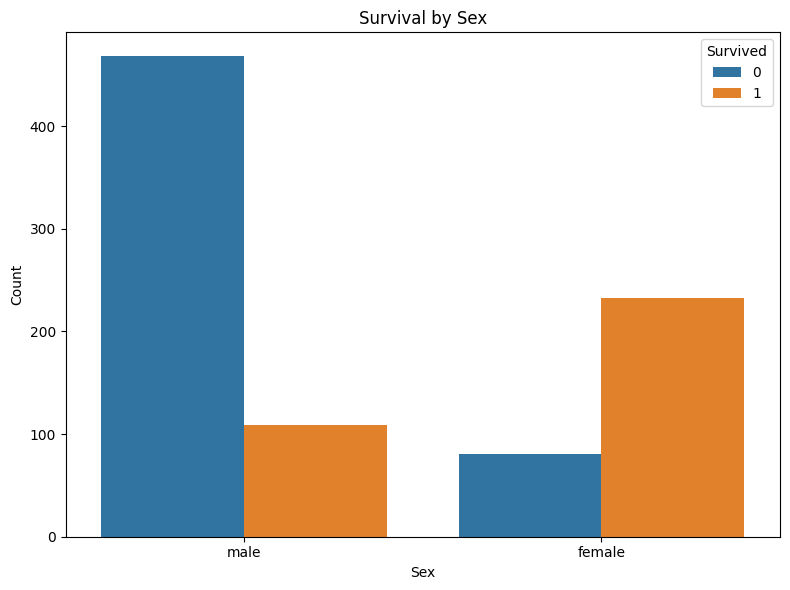

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x="Sex", hue="Survived", data=data)
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [17]:
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = [
    "Noto Sans CJK TC", "Noto Sans TC", "Microsoft JhengHei",
    "PingFang TC", "WenQuanYi Zen Hei", "Arial Unicode MS",
]
chinese_font = next((name for name in font_candidates if name in available_font_names), None)

In [19]:
if chinese_font:
    plt.rcParams["font.family"] = chinese_font
    labels = {
        "survived":"生存者","dead":"死亡者", "sex":"性別",
        "people":"人數","title":"生存者和死亡者的性別分佈",
    }
    print("使用中文字型:",chinese_font)
else:
    labels = {
        "survived": "Survived", "dead": "Died", "sex": "Sex",
        "people": "Count", "title": "Sex Distribution of Survivors and Non-survivors",
    }
    print("未找到合適的中文字型,圖表標題改用英文。")

使用中文字型: Microsoft JhengHei


In [20]:
plt.figure(figsize=(8, 6))

survived_group = data[data["Survived"] == 1]
dead_group = data[data["Survived"] == 0]

sex_categories = ["male", "female"]
survived_counts = survived_group["Sex"].value_counts().reindex(sex_categories, fill_value=0)
dead_counts = dead_group["Sex"].value_counts().reindex(sex_categories, fill_value=0)

<Figure size 800x600 with 0 Axes>

<BarContainer object of 2 artists>

c:\Users\User\anaconda3\envs\ai_practice\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  func(*args, **kwargs)
c:\Users\User\anaconda3\envs\ai_practice\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


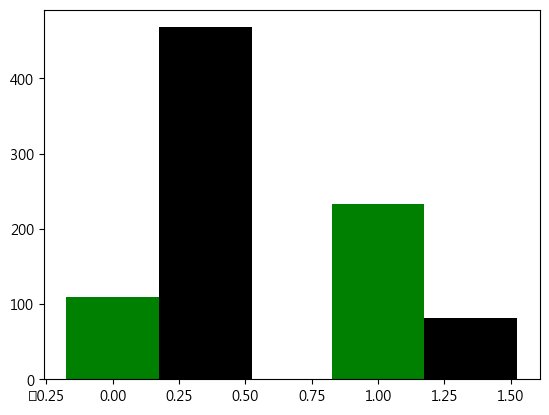

In [22]:
bar_width = 0.35
index = range(len(sex_categories))

plt.bar(index, survived_counts, bar_width, label=labels["survived"], color="green")
plt.bar(
    [i + bar_width for i in index],
    dead_counts,
    bar_width,
    label=labels["dead"],
    color="black",
)

C:\Users\User\AppData\Local\Temp\ipykernel_10972\1356605304.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


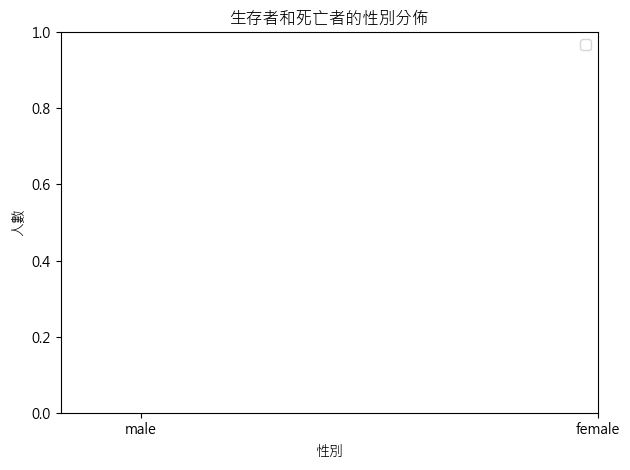

生存者人數: {'male': 109, 'female': 233}
死亡者人數: {'male': 468, 'female': 81}


In [23]:
plt.xlabel(labels["sex"])
plt.ylabel(labels["people"])
plt.title(labels["title"])
plt.xticks([i + bar_width / 2 for i in index], sex_categories)
plt.legend()
plt.tight_layout()
plt.show()

print("生存者人數:", survived_counts.to_dict())
print("死亡者人數:", dead_counts.to_dict())

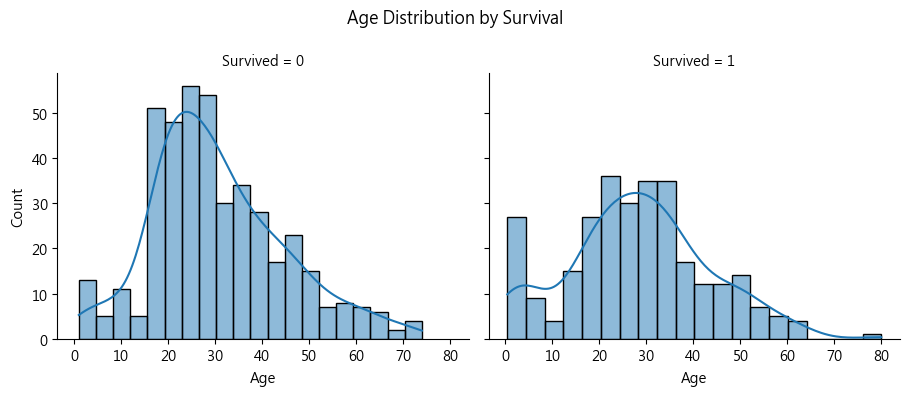

In [24]:
g = sns.FacetGrid(data, col="Survived", height=4, aspect=1.15)
g.map_dataframe(sns.histplot, x="Age", bins=20, kde=True)
g.set_axis_labels("Age", "Count")
g.fig.subplots_adjust (top = 0.82)
g.fig.suptitle("Age Distribution by Survival")
plt.show()

In [26]:
missing_mask = data.isnull()
display(missing_mask.head(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
5,False,False,False,False,False,True,False,False,False,False,True,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,True,False
8,False,False,False,False,False,False,False,False,False,False,True,False
9,False,False,False,False,False,False,False,False,False,False,True,False


In [27]:
missing_values = data.isnull().sum()
print(data.shape)
display(missing_values)

(891, 12)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
data_zero = data.copy()
age_missing_before_zero = data_zero["Age"].isnull().sum()
data_zero["Age"] = data_zero["Age"].fillna(0)
age_missing_after_zero = data_zero["Age"].isnull().sum()

print("填0前 Age 缺失數:", age_missing_before_zero)
print("填0後 Age 缺失數:", age_missing_after_zero)
display(data_zero.loc[[5, 17, 19], ["PassengerId", "Name", "Age"]])

填0前 Age 缺失數: 177
填0後 Age 缺失數: 0


,PassengerId,Name,Age
5,6,"Moran, Mr. James",0.0
17,18,"Williams, Mr. Charles Eugene",0.0
19,20,"Masselmani, Mrs. Fatima",0.0


In [31]:
data_mean = data.copy()
mean_age = data_mean["Age"].mean()
age_missing_before_mean = data_mean["Age"].isnull().sum()
data_mean["Age"] = data_mean ["Age"].fillna (mean_age)
age_missing_after_mean = data_mean["Age"].isnull().sum()

print(f"Age 平均數:{mean_age:.6f}")
print("填平均數前 Age 缺失數:", age_missing_before_mean)
print("填平均數後 Age 缺失數:", age_missing_after_mean)
display(data_mean.loc[[5, 17, 19], ["PassengerId", "Name", "Age"]])

Age 平均數:29.699118
填平均數前 Age 缺失數: 177
填平均數後 Age 缺失數: 0


,PassengerId,Name,Age
5,6,"Moran, Mr. James",29.699118
17,18,"Williams, Mr. Charles Eugene",29.699118
19,20,"Masselmani, Mrs. Fatima",29.699118


In [32]:
data_median = data.copy()
median_age = data_median["Age"].median()
age_missing_before_median = data_median["Age"].isnull().sum()
data_median["Age"] = data_median ["Age"].fillna(median_age)
age_missing_after_median = data_median["Age"].isnull().sum()

print(f"Age 中位數:{median_age:.6f}")
print("填中位數前 Age 缺失數:", age_missing_before_median)
print("填中位數後 Age 缺失數:", age_missing_after_median)
display(data_median.loc[[5, 17, 19], ["PassengerId", "Name", "Age"]])

Age 中位數:28.000000
填中位數前 Age 缺失數: 177
填中位數後 Age 缺失數: 0


,PassengerId,Name,Age
5,6,"Moran, Mr. James",28.0
17,18,"Williams, Mr. Charles Eugene",28.0
19,20,"Masselmani, Mrs. Fatima",28.0


In [33]:
#從原始 train_data 建立副本,原始CSV 與train_data 都不會被改寫
data = train_data.copy()
age_missing_before = data["Age"].isnull().sum()
mean_age = data["Age"].mean()
data["Age"] = data["Age"].fillna(mean_age)
age_missing_after = data["Age"].isnull().sum()

print(f"使用的 Age平均數:{mean_age:.6f}")
print("填補前 Age 缺失數:", age_missing_before)
print("填補後 Age 缺失數:", age_missing_after)
display(data.head(10))

使用的 Age平均數:29.699118
填補前 Age 缺失數: 177
填補後 Age 缺失數: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,NaN,C


In [34]:
embarked_counts_before = data["Embarked"].value_counts()
print("補值前各類別數量:")
display(embarked_counts_before)
print("補值前 Embarked 缺失數:", data["Embarked"].isnull().sum())

補值前各類別數量:


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

補值前 Embarked 缺失數: 2


In [35]:
mode_embarked = data["Embarked"].mode()[0]
print("Embarked 眾數:", mode_embarked)

data["Embarked"] = data["Embarked"].fillna(mode_embarked)
embarked_counts_after = data["Embarked"].value_counts()

print("補值後各類別數量:")
display(embarked_counts_after)
print("補值後 Embarked 缺失數:", data["Embarked"].isnull().sum())

Embarked 眾數: S
補值後各類別數量:


Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

補值後 Embarked 缺失數: 0


In [36]:
cabin_missing = data["Cabin"].isnull().sum()
total_rows = len(data)
cabin_missing_percentage = cabin_missing / total_rows * 100

print("Cabin 缺失數量:", cabin_missing)
print("總資料筆數:", total_rows)
print(f"Cabin 缺失比例:{cabin_missing_percentage:.2f}%")

Cabin 缺失數量: 687
總資料筆數: 891
Cabin 缺失比例:77.10%


In [37]:
if "Cabin" in data.columns:
    data.drop("Cabin", axis=1, inplace=True)

missing_values_after = data.isnull().sum()
print("刪除 Cabin 後 shape:", data.shape)
print("刪除 Cabin 後 columns: ")
print(data.columns.tolist())
print("刪除 Cabin 後各欄缺失數:")
display(missing_values_after)

刪除 Cabin 後 shape: (891, 11)
刪除 Cabin 後 columns: 
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']
刪除 Cabin 後各欄缺失數:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [38]:
assert train_data.shape == (891, 12)
assert test_data.shape == (418, 11)
assert train_data["Age"].isnull().sum() == 177
assert train_data["Cabin"].isnull().sum() == 687
assert train_data["Embarked"].isnull().sum() == 2

assert data["Age"].isnull().sum() == 0
assert data["Embarked"].isnull().sum() == 0
assert "Cabin" not in data.columns

In [39]:
print("全部驗證通過:")
print("- train_data.shape =", train_data.shape)
print("- test_data.shape =", test_data.shape)
print("- Age 補值後缺失數=", data["Age"].isnull().sum())
print("- Embarked 補值後缺失數=", data["Embarked"].isnull().sum())
print("- Cabin 已刪除=", "Cabin" not in data.columns)

全部驗證通過:
- train_data.shape = (891, 12)
- test_data.shape = (418, 11)
- Age 補值後缺失數= 0
- Embarked 補值後缺失數= 0
- Cabin 已刪除= True
